In [16]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from tqdm import tqdm
import torch.optim as optim
from collections import defaultdict
import random

# sklearn – needed for evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize


In [17]:
if torch.cuda.is_available():
    print("Cuda ok")

Cuda ok


# Globals

In [18]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_SAMPLES   = 10000
TRAIN_SIZE    = 0.70   # 70 % train
VAL_SIZE      = 0.15   # 15 % validation
TEST_SIZE     = 0.15   # 15 % test
BATCH_SIZE    = 32

EMBEDDING_DIM         = 256
EMBEDDING_FOURIER_DIM = 64
EMBEDDING_RGB_DIM     = 64
WEIGHT_TASK   = 0.5
LEARNING_RATE = 1e-4
EPOCHS        = 50
DEVICE        = "cuda"

IMAGE_SIZE = (224, 224)
Image.MAX_IMAGE_PIXELS = None


# Utils

## Early Stopping

In [19]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): Quante epoche aspettare dopo l'ultimo miglioramento prima di fermarsi.
            delta (float): Cambiamento minimo nella loss per essere considerato un vero miglioramento.
            path (str): Percorso dove salvare il modello migliore.
        """
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        # Se è la prima epoca, inizializza la best_loss
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # Se la loss attuale non è scesa abbastanza rispetto alla migliore
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # Se la loss è migliorata (è scesa)
        else:
            print(f"Validation loss diminuita ({self.best_loss:.4f} --> {val_loss:.4f}). Salvo il modello!")
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0 # Resetta il contatore

    def save_checkpoint(self, model):
        """Salva i pesi del modello quando la validation loss migliora."""
        torch.save(model.state_dict(), self.path)

## Useful Functions

In [20]:
def model_info(model):
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_in_mb = total_params * 4 / (1024 ** 2)
    print(f"Parametri Totali:       {total_params:,}")
    print(f"Parametri Addestrabili: {trainable_params:,}")
    print(f"Dimensione (float32):   {size_in_mb:.2f} MB")
    return total_params, trainable_params, size_in_mb


def train_multitask_model(model, train_loader, val_loader, epochs=EPOCHS,
                          learning_rate=LEARNING_RATE, device=None,
                          weight_task=WEIGHT_TASK):
    """Train the multi-task model and return a history dict."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    early_stopping = EarlyStopping(patience=5, path='checkpoint_best_model.pth')

    criterion_ai     = nn.CrossEntropyLoss()
    criterion_domain = nn.CrossEntropyLoss()
    optimizer        = optim.AdamW(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'val_loss': [],
        'val_acc_ai': [], 'val_acc_domain': [],
    }

    for epoch in range(epochs):
        # ── TRAIN ──────────────────────────────────────────────────────────
        model.train()
        running_train_loss = 0.0
        train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}] - Train")

        for images, labels in train_loop:
            images       = images.to(device)
            label_ai     = labels['label_ai'].to(device)
            label_domain = labels['label_domain'].to(device)

            optimizer.zero_grad()
            logits_binary, logits_transform = model(images)

            loss_ai     = criterion_ai(logits_binary, label_ai)
            loss_domain = criterion_domain(logits_transform, label_domain)
            total_loss  = weight_task * loss_ai + (1 - weight_task) * loss_domain

            total_loss.backward()
            optimizer.step()

            running_train_loss += total_loss.item()
            train_loop.set_postfix(loss=total_loss.item())

        avg_train_loss = running_train_loss / len(train_loader)

        # ── VALIDATION ─────────────────────────────────────────────────────
        model.eval()
        running_val_loss = 0.0
        correct_ai = correct_domain = total_samples = 0

        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{epochs}] - Val", leave=False)
            for images, labels in val_loop:
                images       = images.to(device)
                label_ai     = labels['label_ai'].to(device)
                label_domain = labels['label_domain'].to(device)

                logits_binary, logits_transform = model(images)
                loss_ai     = criterion_ai(logits_binary, label_ai)
                loss_domain = criterion_domain(logits_transform, label_domain)
                total_loss  = weight_task * loss_ai + (1 - weight_task) * loss_domain

                running_val_loss += total_loss.item()

                _, preds_ai     = torch.max(logits_binary,    dim=1)
                _, preds_domain = torch.max(logits_transform, dim=1)

                total_samples  += images.size(0)
                correct_ai     += (preds_ai     == label_ai).sum().item()
                correct_domain += (preds_domain == label_domain).sum().item()

        avg_val_loss  = running_val_loss / len(val_loader)
        acc_ai        = correct_ai     / total_samples
        acc_domain    = correct_domain / total_samples

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc_ai'].append(acc_ai)
        history['val_acc_domain'].append(acc_domain)

        print(f"--- Epoch {epoch+1} ---")
        print(f"Training Loss:   {avg_train_loss:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}")
        print(f"Val Accuracy AI: {acc_ai*100:.2f}% | Val Accuracy Domain: {acc_domain*100:.2f}%\n")

        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered...")
            break

    print("Training Completed")
    return history


# Data

In [21]:
class RRDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_samples=MAX_SAMPLES):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        
        self.class_ai_to_idx = {"real": 0, "ai": 1}
        self.class_domain_to_idx = {"original": 0, "redigital": 1, "transfer": 2}

        for domain in self.class_domain_to_idx.keys():
            domain_path = self.root_dir / domain
            if not domain_path.exists(): continue
                
            for class_name in self.class_ai_to_idx.keys():
                class_path = domain_path / class_name
                for pattern in ("*.jpg", "*.png"):
                    for img_path in class_path.glob(pattern):
                        self.samples.append((img_path, self.class_ai_to_idx[class_name], self.class_domain_to_idx[domain]))

        
        # --- INIZIO CODICE DI BILANCIAMENTO ---
        if max_samples is not None and max_samples < len(self.samples):
            # A. Creiamo un dizionario per dividere le immagini nei 6 sottogruppi
            grouped_samples = defaultdict(list)
            for sample in self.samples:
                # sample[1] è label_ai, sample[2] è label_domain
                chiave_gruppo = (sample[1], sample[2]) 
                grouped_samples[chiave_gruppo].append(sample)
            
            # B. Calcoliamo quante immagini prendere per ogni "scatola"
            num_gruppi = len(grouped_samples) # Nel tuo caso sarà 6
            quota_per_gruppo = max_samples // num_gruppi
            
            balanced_samples = []
            random.seed(42) # Per riproducibilità
            
            # C. Estraiamo la quota esatta da ogni gruppo
            for chiave, immagini_gruppo in grouped_samples.items():
                # min() ci protegge nel raro caso in cui un gruppo abbia meno immagini della quota
                k = min(quota_per_gruppo, len(immagini_gruppo))
                balanced_samples.extend(random.sample(immagini_gruppo, k))
            
            # D. Mescoliamo tutto alla fine. (Fondamentale, altrimenti il modello
            # vedrebbe prima solo immagini reali originali, poi solo AI, ecc...)
            random.shuffle(balanced_samples)
            
            # Sostituiamo la lista intera con il nostro subset bilanciato
            self.samples = balanced_samples
        # --- FINE CODICE DI BILANCIAMENTO ---

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_ai, label_domain = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, {
            'label_ai': torch.tensor(label_ai, dtype=torch.long),
            'label_domain': torch.tensor(label_domain, dtype=torch.long)
        }

my_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = RRDataset(root_dir=Path(".")/"RRDataset_test"/"RRDataset_final", transform=my_transforms)

In [22]:
dataset_size = len(dataset)

# ── 70 / 15 / 15  split ──────────────────────────────────────────────────────
train_size = int(TRAIN_SIZE * dataset_size)              # 70 %
val_size   = int(VAL_SIZE   * dataset_size)              # 15 %
test_size  = dataset_size - train_size - val_size        # 15 % (remainder)

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Dataset Total size : {dataset_size}")
print(f"Training Set size  : {len(train_dataset)}  ({len(train_dataset)/dataset_size*100:.1f}%)")
print(f"Validation Set size: {len(val_dataset)}   ({len(val_dataset)/dataset_size*100:.1f}%)")
print(f"Test Set size      : {len(test_dataset)}   ({len(test_dataset)/dataset_size*100:.1f}%)")


Dataset Total size: 9996
Training Set size: 7996
Validation Set size: 2000


# Network

## FourierNet


In [23]:
class FourierNetInput(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x_fft = torch.fft.fft2(x)
        x_fft_shifted = torch.fft.fftshift(x_fft)
        x_mag = torch.abs(x_fft_shifted)
        x_phase = torch.angle(x_fft_shifted)
        x_mag = torch.log(x_mag + 1) # Use the log in order to enphasise the differences between the magnitude values of each pixel
        return x_mag, x_phase

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6726604..2.64].


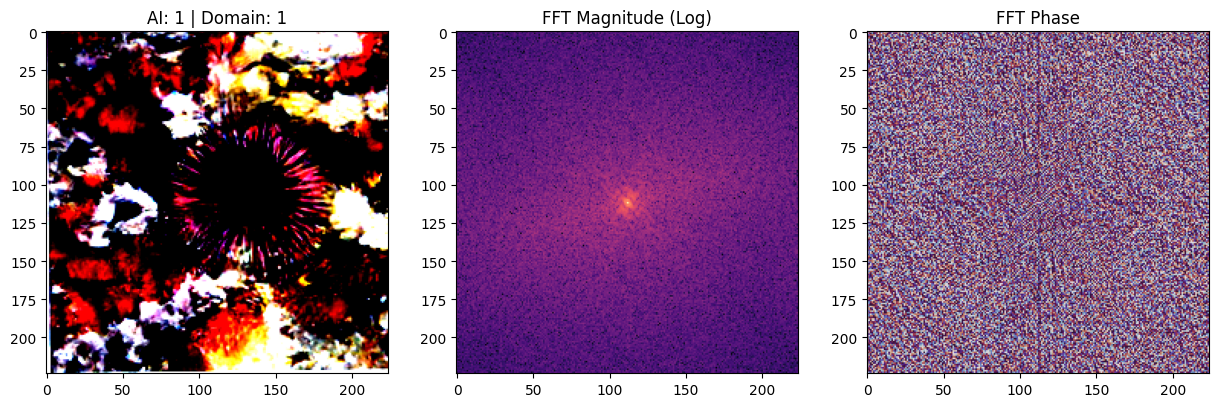

In [24]:
model = FourierNetInput()
images, labels = next(iter(train_loader))
mag, phase = model(images)

index = 0
img_to_show = images[index]
mag_to_show = mag[index]
phs_to_show = phase[index]

img_display = img_to_show.permute(1, 2, 0)
mag_display = mag_to_show[0] # show only the first channel of the magnitude 
phs_display = torch.mean(phs_to_show, dim=0)

label_ai_val = labels['label_ai'][index].item()
label_dom_val = labels['label_domain'][index].item()

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_display)
plt.title(f"AI: {label_ai_val} | Domain: {label_dom_val}")

# Magnitude
plt.subplot(1, 3, 2)
plt.imshow(mag_display, cmap='magma')
plt.title("FFT Magnitude (Log)")

# Phase
plt.subplot(1, 3, 3)
plt.imshow(phs_display, cmap='twilight')
plt.title("FFT Phase")

plt.show()

## BackBone

### FourierNet

In [25]:
class FourierNet(nn.Module):
    def __init__(self, feature_dim=EMBEDDING_FOURIER_DIM):
        super().__init__()

        self.fourier_transform = FourierNetInput()
        
        # 6 input channels: 3 for the magnitude + 3 for the phase
        self.layers = nn.Sequential(
            self._make_layer(6, 32),  # Output: [B, 32, H/2, W/2]
            self._make_layer(32, 64), # Output: [B, 64, H/4, W/4]
            self._make_layer(64, 128) # Output: [B, 128, H/8, W/8]
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) # each channel in input is summarized in a tensor of 1x1, namely a single value -> [B, 128, 1, 1]
        
        # Fully Connected to obtain the informative vector (embedding)
        self.fc_embedding = nn.Sequential(
            nn.Linear(128, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        

    def _make_layer(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), # zero padding (default of padding=1) -> output layer has the same dimension of the input
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # halve the spatial dimension of the input layer H/2, W/2
        )
        
    def forward(self, x):
        # Fourier Transform
        mag, phase = self.fourier_transform(x)
        
        # Concatenation of the magnitude and the phase along the first dimension (channels) 
        x_f = torch.cat((mag, phase), dim=1) # Shape: [B, 6, H, W]
        
        # Convolutional layers
        x_f = self.layers(x_f)
        
        # Embedding extraction
        x_f = self.global_pool(x_f)
        x_f = torch.flatten(x_f, 1)  # Output: [B, 128]
        
        embedding = self.fc_embedding(x_f) # Output: [B, EMBEDDING_FOURIER_DIM]

        return embedding

### RGBNet

In [26]:
class RGBNet(nn.Module):
    def __init__(self, feature_dim= EMBEDDING_RGB_DIM):
        super().__init__()
        
        # Convolutional Architecture
        self.layers = nn.Sequential(
            self._make_layer(3, 32),   # Output: [B, 32, H/2, W/2]
            self._make_layer(32, 64), # Output: [B, 64, H/4, W/4]
            self._make_layer(64, 128) # Output: [B, 128, H/8, W/8]
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) # Output: [B, 128, 1, 1]
        
        # Fully Connected to obtain the informative vector (embedding)
        self.fc_embedding = nn.Sequential(
            nn.Linear(128, feature_dim),
            nn.GELU(),
            nn.Dropout(0.3)
        )

    def _make_layer(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        x = self.layers(x)
        
        # Pooling and Flattening
        x = self.global_pool(x)
        x = torch.flatten(x, 1) # Output: [B, 128]
        
        # Embedding extraction
        embedding = self.fc_embedding(x) # Output: [B, EMBEDDING_RGB_DIM]
        
        return embedding

### Merged

In [27]:
class BackBone(nn.Module):
    def __init__(self, final_embedding_dim= EMBEDDING_DIM):
        super().__init__()
        
        self.fourier_net = FourierNet()
        self.rgb_net = RGBNet()

        feature_dim = EMBEDDING_FOURIER_DIM + EMBEDDING_RGB_DIM
        self.fc_embedding = nn.Sequential(
            nn.Linear(feature_dim, final_embedding_dim),
            nn.GELU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x_f = self.fourier_net(x) # Output [B, feature_dim/2]
        x_rgb = self.rgb_net(x)   # Output [B, feature_dim/2]

        x_c = torch.cat((x_f, x_rgb), dim= 1) # Output [B, feature_dim]

        # Final embedding
        embedding = self.fc_embedding(x_c) # Output [B, EMBEDDING_DIM]

        return embedding

## Two-head Architecture

In [28]:
class BinaryClassifier(nn.Module):
    def __init__(self, embedding_dim: int = EMBEDDING_DIM, hidden_dim: int = 128, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)


class TransformClassifier(nn.Module):
    def __init__(self, embedding_dim: int = EMBEDDING_DIM, hidden_dim: int = 128, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3)
        )

    def forward(self, x):
        return self.net(x)


class MultiHeadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.binary_head = BinaryClassifier()
        self.transform_head = TransformClassifier()

    def forward(self, emb_fused):
        logits_binary = self.binary_head(emb_fused)
        logits_transform = self.transform_head(emb_fused)
        return logits_binary, logits_transform

## Final Model

In [29]:
class MultiTaskNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.backbone = BackBone()
        self.multi_head = MultiHeadModel()

    def forward(self, x):
        x_emb = self.backbone(x)
        logits_binary, logits_transform = self.multi_head(x_emb)

        return logits_binary, logits_transform


# Training

In [30]:
model = MultiTaskNet()
model_info(model)

Parametri Totali:       305,253
Parametri Addestrabili: 305,253
Dimensione (float32):   1.16 MB


(305253, 305253, 1.1644477844238281)

In [31]:
history = train_multitask_model(model, train_loader, val_loader, device=DEVICE)


Epoch [1/50] - Train: 100%|██████████| 250/250 [01:39<00:00,  2.52it/s, loss=0.773]


--- Epoch 1 ---
Training Loss:   0.8553
Validation Loss: 0.7593
Val Accuracy AI: 70.00% | Val Accuracy Domain: 50.15%



Epoch [2/50] - Train: 100%|██████████| 250/250 [01:42<00:00,  2.44it/s, loss=0.776]


--- Epoch 2 ---
Training Loss:   0.7561
Validation Loss: 0.7038
Val Accuracy AI: 70.55% | Val Accuracy Domain: 55.05%

Validation loss diminuita (0.7593 --> 0.7038). Salvo il modello!


Epoch [3/50] - Train: 100%|██████████| 250/250 [01:42<00:00,  2.45it/s, loss=0.649]


...

--- Epoch 34 ---
Training Loss:   0.5529
Validation Loss: 0.5504
Val Accuracy AI: 80.75% | Val Accuracy Domain: 60.00%

EarlyStopping counter: 3 out of 5


Epoch [35/50] - Train: 100%|██████████| 250/250 [01:35<00:00,  2.61it/s, loss=0.562]


--- Epoch 35 ---
Training Loss:   0.5452
Validation Loss: 0.5563
Val Accuracy AI: 81.10% | Val Accuracy Domain: 60.10%

EarlyStopping counter: 4 out of 5


Epoch [36/50] - Train: 100%|██████████| 250/250 [01:38<00:00,  2.53it/s, loss=0.471]
                                                                    

--- Epoch 36 ---
Training Loss:   0.5481
Validation Loss: 0.5462
Val Accuracy AI: 82.05% | Val Accuracy Domain: 59.20%

EarlyStopping counter: 5 out of 5
Early stopping triggered...
Training Completed


# Evaluation

## Learning Curves

In [ ]:
def plot_learning_curves(history):
    epochs_ran = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # — Loss —
    axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   linewidth=2)
    axes[0].set_title('Loss per Epoch', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # — Accuracy —
    axes[1].plot(epochs_ran, [a*100 for a in history['val_acc_ai']],
                 label='Val Acc AI (real/fake)', linewidth=2)
    axes[1].plot(epochs_ran, [a*100 for a in history['val_acc_domain']],
                 label='Val Acc Domain (transform)', linewidth=2)
    axes[1].set_title('Validation Accuracy per Epoch', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.suptitle('Training History – MultiTaskNet', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_learning_curves(history)


## Test-Set Inference

In [ ]:
def collect_predictions(model, loader, device=DEVICE):
    """Return arrays of true labels, predicted labels and softmax probabilities."""
    model.eval()
    model.to(device)

    all_true_ai,     all_pred_ai,     all_prob_ai     = [], [], []
    all_true_domain, all_pred_domain, all_prob_domain = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Inference'):
            images       = images.to(device)
            label_ai     = labels['label_ai'].to(device)
            label_domain = labels['label_domain'].to(device)

            logits_binary, logits_transform = model(images)

            prob_ai     = F.softmax(logits_binary,    dim=1)
            prob_domain = F.softmax(logits_transform, dim=1)

            _, preds_ai     = torch.max(logits_binary,    dim=1)
            _, preds_domain = torch.max(logits_transform, dim=1)

            all_true_ai.extend(label_ai.cpu().numpy())
            all_pred_ai.extend(preds_ai.cpu().numpy())
            all_prob_ai.extend(prob_ai.cpu().numpy())

            all_true_domain.extend(label_domain.cpu().numpy())
            all_pred_domain.extend(preds_domain.cpu().numpy())
            all_prob_domain.extend(prob_domain.cpu().numpy())

    return {
        'true_ai':     np.array(all_true_ai),
        'pred_ai':     np.array(all_pred_ai),
        'prob_ai':     np.array(all_prob_ai),
        'true_domain': np.array(all_true_domain),
        'pred_domain': np.array(all_pred_domain),
        'prob_domain': np.array(all_prob_domain),
    }

# Load best checkpoint before running test inference
model.load_state_dict(torch.load('checkpoint_best_model.pth', map_location=DEVICE))
test_preds = collect_predictions(model, test_loader)
print('Test inference done.')


## Confusion Matrices

Two confusion matrices: one for the **AI-detection** head (real vs fake) and one for the **transformation** head (original / internet-transmitted / re-digitized).

In [ ]:
AI_LABELS     = ['real', 'ai']
DOMAIN_LABELS = ['original', 'redigital', 'transfer']


def plot_confusion_matrix(y_true, y_pred, class_names, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

    annot = np.array(
        [[f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)"
          for j in range(cm.shape[1])]
         for i in range(cm.shape[0])]
    )

    sns.heatmap(
        cm_norm, annot=annot, fmt='', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        vmin=0, vmax=1, ax=ax, linewidths=.5
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(test_preds['true_ai'],     test_preds['pred_ai'],
                      AI_LABELS,     'Task 1 – AI Detection (real vs fake)', axes[0])
plot_confusion_matrix(test_preds['true_domain'], test_preds['pred_domain'],
                      DOMAIN_LABELS, 'Task 2 – Transformation Type',         axes[1])
plt.suptitle('Confusion Matrices – Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Classification Reports

In [ ]:
print('=' * 55)
print('TASK 1 – AI Detection (real vs fake)')
print('=' * 55)
print(classification_report(test_preds['true_ai'], test_preds['pred_ai'],
                              target_names=AI_LABELS, digits=4))

print('=' * 55)
print('TASK 2 – Transformation Type Classification')
print('=' * 55)
print(classification_report(test_preds['true_domain'], test_preds['pred_domain'],
                              target_names=DOMAIN_LABELS, digits=4))


## ROC Curves and AUC

One-vs-rest ROC curve for each class in both tasks.

In [ ]:
def plot_roc_curves(y_true, y_prob, class_names, title, ax):
    n_classes = len(class_names)
    y_bin     = label_binarize(y_true, classes=list(range(n_classes)))

    colors = plt.cm.tab10.colors
    for c in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_prob[:, c])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[c], linewidth=2,
                label=f'{class_names[c]} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_roc_curves(test_preds['true_ai'],     test_preds['prob_ai'],
                AI_LABELS,     'ROC – Task 1: AI Detection',       axes[0])
plot_roc_curves(test_preds['true_domain'], test_preds['prob_domain'],
                DOMAIN_LABELS, 'ROC – Task 2: Transformation Type', axes[1])
plt.suptitle('ROC Curves – Test Set (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Per-Class Metrics Bar Chart

Precision, Recall and F1-Score for each class, for both tasks.

In [ ]:
def plot_per_class_metrics(y_true, y_pred, class_names, title):
    from sklearn.metrics import precision_recall_fscore_support
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(class_names))), average=None
    )

    x      = np.arange(len(class_names))
    width  = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x - width, prec, width, label='Precision', color='steelblue')
    b2 = ax.bar(x,          rec,  width, label='Recall',    color='darkorange')
    b3 = ax.bar(x + width, f1,   width, label='F1-Score',  color='forestgreen')

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_per_class_metrics(test_preds['true_ai'],     test_preds['pred_ai'],
                       AI_LABELS,     'Per-Class Metrics – Task 1: AI Detection')
plot_per_class_metrics(test_preds['true_domain'], test_preds['pred_domain'],
                       DOMAIN_LABELS, 'Per-Class Metrics – Task 2: Transformation Type')


## Accuracy Breakdown by Transformation Category

For **Task 1 (AI detection)**, we measure accuracy *separately* for each post-processing category (original, redigital, transfer). This reveals which transformations are most harmful to detection performance.

In [ ]:
def plot_accuracy_by_domain(true_ai, pred_ai, true_domain, domain_names):
    """Bar chart: AI-detection accuracy split by transformation category."""
    accs = {}
    for d_idx, d_name in enumerate(domain_names):
        mask = (true_domain == d_idx)
        if mask.sum() == 0:
            accs[d_name] = 0.0
            continue
        accs[d_name] = accuracy_score(true_ai[mask], pred_ai[mask])

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(list(accs.keys()), [v*100 for v in accs.values()],
                  color=['steelblue', 'darkorange', 'forestgreen'])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='Random baseline (50%)')
    ax.set_ylim(0, 110)
    ax.set_ylabel('AI-Detection Accuracy (%)')
    ax.set_title('Task 1 Accuracy per Post-Processing Category\n'
                 '(which transformations degrade AI detection?)', fontsize=12)
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print('\nDetailed breakdown:')
    for name, acc in accs.items():
        print(f'  {name:12s}: {acc*100:.2f}%')


plot_accuracy_by_domain(
    test_preds['true_ai'],     test_preds['pred_ai'],
    test_preds['true_domain'], DOMAIN_LABELS
)


## Ablation Study – Loss Weight Analysis

The combined loss is defined as:

$$\mathcal{L} = \lambda \cdot \mathcal{L}_{AI} + (1-\lambda) \cdot \mathcal{L}_{domain}$$

Here we train the model with multiple values of $\lambda \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$ and compare how the trade-off affects **Task 1 (AI detection)** and **Task 2 (transformation classification)** accuracy on the **validation set**.

This is the core **ablation study** required by the project specification.

In [ ]:
def run_ablation_study(dataset, weight_values=None, epochs_ablation=20):
    """
    Train a fresh model for each weight value and collect validation accuracies.
    Returns a dict: {weight: {'acc_ai': float, 'acc_domain': float}}
    """
    if weight_values is None:
        weight_values = [0.1, 0.3, 0.5, 0.7, 0.9]

    # Use same 70/15/15 split as main training
    ds_size    = len(dataset)
    t_size     = int(0.70 * ds_size)
    v_size     = int(0.15 * ds_size)
    te_size    = ds_size - t_size - v_size
    gen        = torch.Generator().manual_seed(SEED)
    tr_ds, vl_ds, _ = random_split(dataset, [t_size, v_size, te_size], generator=gen)
    abl_train  = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
    abl_val    = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    results = {}
    for w in weight_values:
        print(f'\n>>> Training with λ = {w}')
        m = MultiTaskNet()
        hist = train_multitask_model(
            m, abl_train, abl_val,
            epochs=epochs_ablation, weight_task=w, device=DEVICE
        )
        # Take the best val accuracy reached during training
        best_epoch = int(np.argmin(hist['val_loss']))
        results[w] = {
            'acc_ai':     hist['val_acc_ai'][best_epoch],
            'acc_domain': hist['val_acc_domain'][best_epoch],
            'val_loss':   hist['val_loss'][best_epoch],
        }
        print(f'   Best epoch {best_epoch+1}: '
              f'acc_ai={results[w]["acc_ai"]*100:.2f}% | '
              f'acc_domain={results[w]["acc_domain"]*100:.2f}%')

    return results


# NOTE: set epochs_ablation to a lower value (e.g. 15-20) to keep runtime manageable
ablation_results = run_ablation_study(dataset, epochs_ablation=15)


In [ ]:
def plot_ablation_results(ablation_results):
    weights    = sorted(ablation_results.keys())
    acc_ai     = [ablation_results[w]['acc_ai']     * 100 for w in weights]
    acc_domain = [ablation_results[w]['acc_domain'] * 100 for w in weights]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Line plot ────────────────────────────────────────────────────────────
    axes[0].plot(weights, acc_ai,     'o-', color='steelblue',   linewidth=2, markersize=8,
                 label='Task 1 – AI Detection')
    axes[0].plot(weights, acc_domain, 's-', color='darkorange',  linewidth=2, markersize=8,
                 label='Task 2 – Transformation')
    for w, a, b in zip(weights, acc_ai, acc_domain):
        axes[0].annotate(f'{a:.1f}%', (w, a),  textcoords='offset points', xytext=(0, 8),  fontsize=8)
        axes[0].annotate(f'{b:.1f}%', (w, b),  textcoords='offset points', xytext=(0, -14), fontsize=8)
    axes[0].set_xlabel('λ (weight of AI-detection loss)')
    axes[0].set_ylabel('Validation Accuracy (%)')
    axes[0].set_title('Accuracy Trade-off vs λ', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)
    axes[0].set_xticks(weights)

    # ── Bar chart ────────────────────────────────────────────────────────────
    x     = np.arange(len(weights))
    width = 0.35
    b1 = axes[1].bar(x - width/2, acc_ai,     width, label='Task 1 – AI Detection', color='steelblue')
    b2 = axes[1].bar(x + width/2, acc_domain, width, label='Task 2 – Transformation', color='darkorange')
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                         f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f'λ={w}' for w in weights])
    axes[1].set_ylabel('Validation Accuracy (%)')
    axes[1].set_title('Grouped Bar – Task Accuracy per λ', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

    plt.suptitle('Ablation Study: Loss Weight λ vs Task Accuracy', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary table
    print('\n── Ablation Summary ─────────────────────────────────────────────')
    print(f'{"λ":>6} | {"Acc Task1 (AI)":>16} | {"Acc Task2 (Domain)":>20} | {"Δ":>8}')
    print('-' * 60)
    for w in sorted(ablation_results.keys()):
        a1 = ablation_results[w]['acc_ai']     * 100
        a2 = ablation_results[w]['acc_domain'] * 100
        print(f'{w:>6.1f} | {a1:>16.2f}% | {a2:>20.2f}% | {a1-a2:>+8.2f}%')


plot_ablation_results(ablation_results)


## Unimodal Baselines vs Multi-Task

The project specification asks to compare the joint model against **unimodal baselines** (i.e., models trained on only Task 1 *or* Task 2).

Here we define two thin wrappers that re-use the shared backbone but are trained on a single task, then compare their test accuracy against the multi-task model.

In [ ]:
class UnimodalNetAI(nn.Module):
    """Backbone + AI head only (trained with loss_ai, weight_task=1.0)."""
    def __init__(self):
        super().__init__()
        self.backbone    = BackBone()
        self.binary_head = BinaryClassifier()

    def forward(self, x):
        emb = self.backbone(x)
        return self.binary_head(emb), torch.zeros(x.size(0), 3).to(x.device)  # dummy domain logits


class UnimodalNetDomain(nn.Module):
    """Backbone + Domain head only (trained with loss_domain, weight_task=0.0)."""
    def __init__(self):
        super().__init__()
        self.backbone        = BackBone()
        self.transform_head  = TransformClassifier()

    def forward(self, x):
        emb = self.backbone(x)
        return torch.zeros(x.size(0), 2).to(x.device), self.transform_head(emb)  # dummy ai logits


print('Training Unimodal baseline – Task 1 (AI detection only, λ=1.0) ...')
unimodal_ai = UnimodalNetAI()
train_multitask_model(unimodal_ai, train_loader, val_loader,
                      epochs=15, weight_task=1.0, device=DEVICE)

print('\nTraining Unimodal baseline – Task 2 (Domain only, λ=0.0) ...')
unimodal_domain = UnimodalNetDomain()
train_multitask_model(unimodal_domain, train_loader, val_loader,
                      epochs=15, weight_task=0.0, device=DEVICE)


In [ ]:
preds_uni_ai     = collect_predictions(unimodal_ai,     test_loader)
preds_uni_domain = collect_predictions(unimodal_domain, test_loader)

def compare_baselines(test_preds, preds_uni_ai, preds_uni_domain):
    scenarios = {
        'Unimodal\n(AI only)':     {'ai': preds_uni_ai['pred_ai'],     'domain': preds_uni_ai['pred_domain']},
        'Unimodal\n(Domain only)': {'ai': preds_uni_domain['pred_ai'], 'domain': preds_uni_domain['pred_domain']},
        'Multi-Task\n(λ=0.5)':     {'ai': test_preds['pred_ai'],       'domain': test_preds['pred_domain']},
    }
    true_ai     = test_preds['true_ai']
    true_domain = test_preds['true_domain']

    model_names, accs_ai, accs_domain = [], [], []
    for name, preds in scenarios.items():
        model_names.append(name)
        accs_ai.append(accuracy_score(true_ai,     preds['ai'])     * 100)
        accs_domain.append(accuracy_score(true_domain, preds['domain']) * 100)

    x     = np.arange(len(model_names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - width/2, accs_ai,     width, label='Task 1 – AI Detection',   color='steelblue')
    b2 = ax.bar(x + width/2, accs_domain, width, label='Task 2 – Transformation', color='darkorange')
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Unimodal Baselines vs Multi-Task – Test Accuracy', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

compare_baselines(test_preds, preds_uni_ai, preds_uni_domain)
